In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

df_report = pd.read_csv('reporting.csv')

# parse
df_report["date"] = pd.to_datetime(df_report["date"], dayfirst=True).dt.date
df_report = df_report[["date", "weight"]].dropna()
df_report = df_report.sort_values("date").reset_index(drop=True)

dataset = df_report[["weight"]].values.astype("float32")

# split data into train and test
train_size = int(len(dataset) * 0.67)
train_raw = dataset[:train_size]
test_raw = dataset[train_size:]

#scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)

train = scaler.transform(train_raw)
test = scaler.transform(test_raw)

# convert series to supervised learning
def create_dataset(dataset, look_back=3):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back), 0])
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

look_back = 5
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

trainX = np.reshape(trainX, (trainX.shape[0], look_back, 1))
testX = np.reshape(testX, (testX.shape[0], look_back, 1))

# LSTM
model = Sequential()
model.add(LSTM(4, input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# train
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

# predict
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# iverse transform predictions and actual values
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

# RMSE
trainScore = np.sqrt(mean_squared_error(trainY, trainPredict))
testScore = np.sqrt(mean_squared_error(testY, testPredict))
print('Train Score: %.2f RMSE' % trainScore)
print('Test Score: %.2f RMSE' % testScore)

# naive baseline, predict next weight = previous weight
baseline_train = trainX[:, -1, 0].reshape(-1, 1)
baseline_test = testX[:, -1, 0].reshape(-1, 1)

baseline_train = scaler.inverse_transform(baseline_train)
baseline_test = scaler.inverse_transform(baseline_test)

baseline_train_rmse = np.sqrt(mean_squared_error(trainY, baseline_train))
baseline_test_rmse = np.sqrt(mean_squared_error(testY, baseline_test))

print('Naive Baseline Train RMSE: %.2f' % baseline_train_rmse)
print('Naive Baseline Test RMSE: %.2f' % baseline_test_rmse)

train_mape = mean_absolute_percentage_error(trainY, trainPredict) * 100
test_mape = mean_absolute_percentage_error(testY, testPredict) * 100

print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test MAPE: {test_mape:.2f}%")


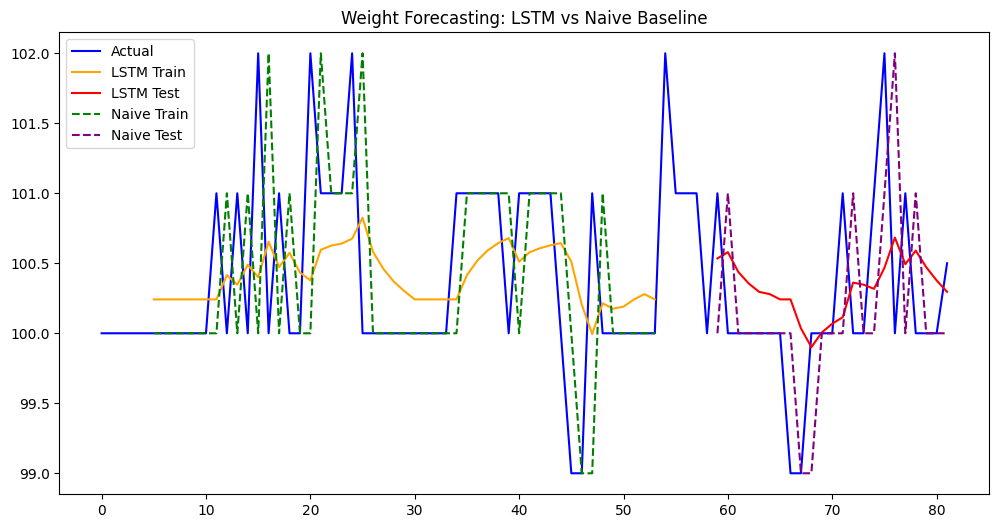

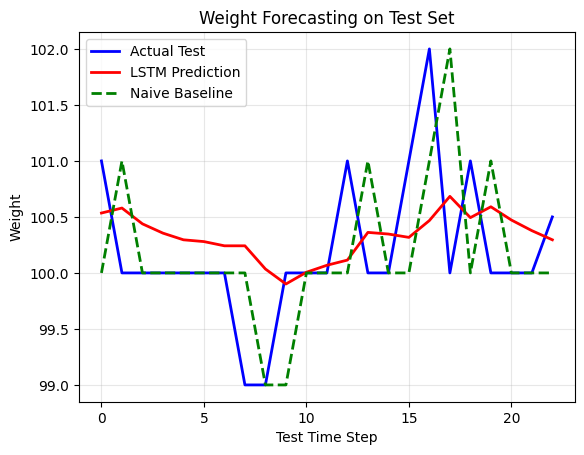

In [5]:

plt.figure(figsize=(12, 6))

# true values
plt.plot(df_report["weight"].values, label="Actual", color="blue")

# LSTM train predictions
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:look_back + len(trainPredict), 0] = trainPredict[:, 0]

# LSTM test predictions
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
test_start = train_size + look_back
testPredictPlot[test_start:test_start + len(testPredict), 0] = testPredict[:, 0]

# naive baseline train predictions
baselineTrainPlot = np.empty_like(dataset)
baselineTrainPlot[:, :] = np.nan
baselineTrainPlot[look_back:look_back + len(baseline_train), 0] = baseline_train[:, 0]

# naive baseline test predictions
baselineTestPlot = np.empty_like(dataset)
baselineTestPlot[:, :] = np.nan
baselineTestPlot[test_start:test_start + len(baseline_test), 0] = baseline_test[:, 0]

# plot all
plt.plot(trainPredictPlot, label="LSTM Train", color="orange")
plt.plot(testPredictPlot, label="LSTM Test", color="red")
plt.plot(baselineTrainPlot, label="Naive Train", color="green", linestyle="--")
plt.plot(baselineTestPlot, label="Naive Test", color="purple", linestyle="--")

plt.legend()
plt.title("Weight Forecasting: LSTM vs Naive Baseline")
plt.show()


x = np.arange(len(testY))

plt.plot(x, testY, label="Actual Test", color="blue", linewidth=2)
plt.plot(x, testPredict, label="LSTM Prediction", color="red", linewidth=2)
plt.plot(x, baseline_test, label="Naive Baseline", color="green", linestyle="--", linewidth=2)

plt.title("Weight Forecasting on Test Set")
plt.xlabel("Test Time Step")
plt.ylabel("Weight")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()